In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [4]:
books = soup.find_all("article", class_="product_pod")

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text

    print(title, "-", price)

A Light in the Attic - Â£51.77
Tipping the Velvet - Â£53.74
Soumission - Â£50.10
Sharp Objects - Â£47.82
Sapiens: A Brief History of Humankind - Â£54.23
The Requiem Red - Â£22.65
The Dirty Little Secrets of Getting Your Dream Job - Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull - Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics - Â£22.60
The Black Maria - Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) - Â£13.99
Shakespeare's Sonnets - Â£20.66
Set Me Free - Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) - Â£52.29
Rip it Up and Start Again - Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 - Â£57.25
Olio - Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 - Â£37.59
Libertarianism for Beginners - Â£51.33
It's Only the Himalayas - Â£45.17


In [5]:
data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text

    data.append({
        "Book_Title": title,
        "Price": price
    })

df = pd.DataFrame(data)

df.head()

,Book_Title,Price
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


In [8]:
print(df.dtypes)
print(df.head())

Book_Title    object
Price         object
dtype: object
                              Book_Title   Price
0                   A Light in the Attic  Â51.77
1                     Tipping the Velvet  Â53.74
2                             Soumission  Â50.10
3                          Sharp Objects  Â47.82
4  Sapiens: A Brief History of Humankind  Â54.23


In [10]:
df['Price'] = df['Price'].str.replace('Â', '', regex=False)
df['Price'] = df['Price'].str.replace('£', '', regex=False)

df['Price'] = df['Price'].astype(float)

df.head()

,Book_Title,Price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


In [11]:
df.to_csv("CodeAlpha_Task1_Web_Scraping.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [12]:
print("Number of Books:", len(df))
print("Average Price:", df['Price'].mean())
print("Minimum Price:", df['Price'].min())
print("Maximum Price:", df['Price'].max())

Number of Books: 20
Average Price: 38.048500000000004
Minimum Price: 13.99
Maximum Price: 57.25


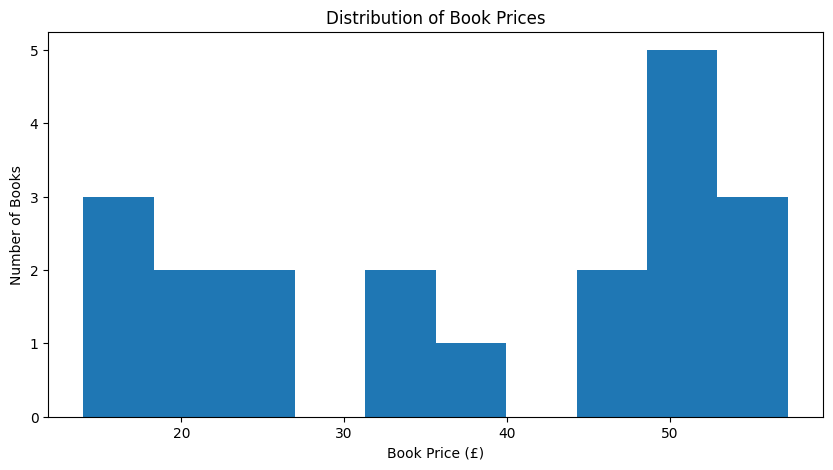

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['Price'], bins=10)

plt.xlabel('Book Price (£)')
plt.ylabel('Number of Books')
plt.title('Distribution of Book Prices')

plt.show()

In [14]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape: (20, 2)

Columns:
Index(['Book_Title', 'Price'], dtype='object')

First 5 rows:


,Book_Title,Price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


In [15]:
from google.colab import files

files.download("CodeAlpha_Task1_Web_Scraping.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>